# 1. Introduction

**NLP - Airplane Sentiment Analysis**  

**Nama    :** Muhammad Damar Triwardana

**Dataset :** Twitter US Airline Sentiment   

**Sumber  :** Kaggle – CrowdFlower (Figure Eight) - https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Latar Belakang  :**  Media sosial, khususnya Twitter, menjadi salah satu platform utama bagi pelanggan untuk menyampaikan pengalaman, keluhan, maupun apresiasi terhadap layanan maskapai penerbangan. Opini yang disampaikan secara terbuka ini membentuk persepsi publik dan dapat berdampak langsung terhadap reputasi perusahaan. Namun, volume tweet yang sangat besar membuat proses analisis sentimen secara manual menjadi tidak efisien dan rentan terhadap subjektivitas. Oleh karena itu, diperlukan pendekatan Natural Language Processing (NLP) dan Deep Learning untuk melakukan klasifikasi sentimen secara otomatis. Dengan memanfaatkan Artificial Neural Network (ANN) berbasis TensorFlow.

**Objektif    :** Membangun model ANN untuk mengklasifikasikan sentimen tweet pelanggan maskapai ke dalam 3 kelas yaitu, Negative, Neutral dan Positive.

**URL Model:** https://huggingface.co/spaces/J1nTomank/P2G7_Muhammad_Damar_Model

# 2. Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & Text Processing
import re
import string

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

# Model Saving
import pickle

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\damar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\damar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\damar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 3. Data Loading

In [2]:
# Memanggil dataset
df = pd.read_csv('Tweets.csv')
df.head()

# Melihat informasi dataset
df.info()

# Mengecek ukuran dataset
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

(14640, 15)

Dari output diatas kita dapat mengetahui informasi dari dataset/dataframe yang digunakan. Seperti, terdapat 14640 baris dengan 15 kolom, diketahui juga tipe datanya yang dimana mayoritas datanya itu berupa object/string lalu diikuti dengan tipe data numerikal (float dan integer).

In [3]:
# Mengetahui total dari tiap kategori pada suatu kolom ['airline_sentiment']
df['airline_sentiment'].value_counts()

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Dari output diatas, bisa diasumsikan bahwa isi dari kolom ['airline_sentiment'] ini imbalanced yang dimana kategori 'negatif' lebih banyak dibandingkan dengan kategori 'netral' dan 'positif'.

# 4. Exploratory Data Analysis

## 4.1. Distribusi Sentimen Tweet

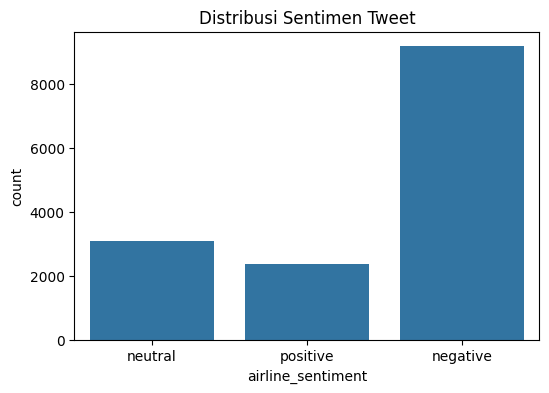

In [4]:
# Membuat countplot
plt.figure(figsize=(6,4))
sns.countplot(x='airline_sentiment', data=df)
plt.title("Distribusi Sentimen Tweet")
plt.show()

Disini dapat terlihat dengan jelas bahwa memang isi dari kolom 'airline_sentiment' itu imbalanced, yang dimana kategori 'negatif' itu menjadi mayoritas dibandingkan dengan 2 kategori lainnya ('netral' dan 'positif').

## 4.2. Distribusi Panjang Tweet

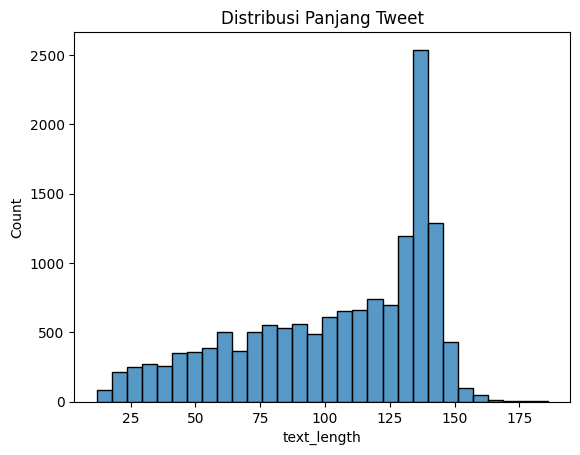

In [5]:
# Plot Histogram
df['text_length'] = df['text'].apply(len) 
sns.histplot(df['text_length'], bins=30) 
plt.title('Distribusi Panjang Tweet') 
plt.show()

Rata-rata panjang dari tiap tweet, itu tidak terlalu panjang, tidak lebih dari 200 kata, dan paling sering atau paling banyak itu ada diantara 125-150 kata, dan yang diatas 150 itu sangat sedikit, mungkin tidak sampai lebih dari 100.

# 5. Feature Engineering

## 5.1. Cleaning

In [6]:
# Membersihkan kolom target
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text_nltk(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    tokens = word_tokenize(text)
    tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in stop_words and word.isalpha()
    ]
    
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text_nltk)
df[['text', 'clean_text']].head()

,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plu youv ad commerci experi tacki
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take anoth trip
3,@VirginAmerica it's really aggressive to blast...,realli aggress blast obnoxi entertain guest fa...
4,@VirginAmerica and it's a really big bad thing...,realli big bad thing


Dari output di atas, dapat dilihat bahwa proses text preprocessing berhasil membersihkan teks dari elemen yang tidak relevan seperti mention, tanda baca, dan perbedaan huruf kapital. Hal ini terlihat dari kolom clean_text yang isinya menjadi lebih ringkas dan fokus pada kata-kata utama yang merepresentasikan isi kalimat, sehingga noise pada data dapat dikurangi sebelum masuk ke tahap pemodelan.

Selain itu, penggunaan stopwords removal dan stemming membantu menyederhanakan kata tanpa menghilangkan makna sentimen yang terkandung di dalamnya. Kata-kata umum yang tidak berpengaruh terhadap sentimen dihapus, sementara variasi bentuk kata diseragamkan ke bentuk dasarnya. Dengan demikian, teks menjadi lebih konsisten dan memudahkan model dalam mengenali pola yang berkaitan dengan sentimen positif maupun negatif.

## 5.2. Target Encoding

In [7]:
# Inisialisasi LabelEncoder untuk mengubah label kategorikal menjadi numerik
le = LabelEncoder() 
df['sentiment_label'] = le.fit_transform(df['airline_sentiment'])

le.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

LabelEncoder digunakan untuk mengonversi label sentimen kategorikal menjadi bentuk numerik agar dapat diproses oleh model machine learning. Urutan kelas yang dihasilkan menunjukkan bahwa sentimen negative diberi label 0, neutral sebagai 1, dan positive sebagai 2. Proses ini diperlukan karena algoritma pembelajaran mesin tidak dapat bekerja langsung dengan data bertipe teks, sehingga label target harus direpresentasikan dalam bentuk angka tanpa mengubah makna kelas aslinya.

## 5.3. Train & Test Split, Validation

In [8]:
# Memisahkan fitur (X) dan target (y)
X = df['clean_text']
y = df['sentiment_label']

# Membagi data menjadi training set (80%) dan temporary set (20%)
X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)

# Membagi temporary set menjadi validation set (10%) dan test set (10%)
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

Dataset dibagi menjadi tiga bagian, yaitu data training, validation, dan testing. Kolom clean_text digunakan sebagai fitur (X), sedangkan sentiment_label digunakan sebagai target (y). Pembagian awal dilakukan dengan memisahkan 80% data sebagai data latih dan 20% sebagai data sementara, yang bertujuan agar model memiliki cukup data untuk belajar pola sentimen dari teks.

Selanjutnya, data sementara tersebut kembali dibagi menjadi data validation dan data testing dengan proporsi yang sama, sehingga masing-masing memperoleh 10% dari total data. Penggunaan parameter stratify memastikan distribusi kelas sentimen pada setiap subset tetap seimbang dan konsisten dengan data aslinya. Hal ini digunakan agar performa model dapat dievaluasi secara adil dan tidak bias terhadap salah satu kelas sentimen.

## 5.4. Tokenization & Padding

In [9]:
# Membuat tokenizer dengan batas maksimal 10.000 kata
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# Mengubah teks menjadi representasi numerik (sequence of integers)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Menentukan panjang maksimum sequence
max_len = 50

# Melakukan padding agar seluruh sequence memiliki panjang yang sama
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

Data teks diubah menjadi bentuk numerik menggunakan tokenizer agar dapat diproses oleh model deep learning. Tokenizer akan memetakan setiap kata menjadi sebuah indeks berdasarkan frekuensi kemunculannya pada data training, sehingga teks yang sebelumnya berupa string dapat direpresentasikan dalam bentuk angka. Setelah itu, dilakukan padding untuk menyeragamkan panjang setiap sequence teks. Hal ini diperlukan karena model neural network membutuhkan input dengan dimensi yang konsisten. Dengan menetapkan panjang maksimum tertentu, model dapat memproses seluruh data secara lebih stabil dan efisien tanpa terpengaruh oleh perbedaan panjang kalimat.

## 5.5. Class Weight

In [10]:
# Menghitung class weight untuk mengatasi masalah class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Mengubah hasil class weight menjadi dictionary
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: 0.5316628081165736, 1: 1.5748285599031868, 2: 2.0656084656084657}

Dari output di atas, dapat diketahui bahwa setiap kelas memiliki bobot yang berbeda-beda. Kelas dengan label 0 (negative) memiliki bobot paling kecil, sementara kelas 1 (neutral) dan terutama 2 (positive) memiliki bobot yang lebih besar. Hal ini menunjukkan bahwa jumlah data pada kelas negatif jauh lebih dominan dibandingkan kelas lainnya. Pemberian class weight ini bertujuan agar model tidak bias terhadap kelas mayoritas. Dengan bobot yang lebih besar pada kelas minoritas, model akan “dipaksa” untuk lebih memperhatikan kesalahan prediksi pada kelas neutral dan positive, sehingga performa model menjadi lebih seimbang dan tidak hanya unggul dalam memprediksi kelas negatif saja.

# 6. ANN Training

## 6.1. Model Definition

In [11]:
# Baseline ANN model menggunakan Sequential API
model_baseline = Sequential([
Embedding(10000, 32, input_length=max_len),
GlobalAveragePooling1D(),
Dense(64, activation='relu'),
Dropout(0.3),
Dense(3, activation='softmax')
])


model_baseline.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)


model_baseline.summary()

c:\Users\damar\miniconda3\envs\h8_env\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model baseline ini dirancang cukup sederhana untuk tugas klasifikasi sentimen. Embedding layer digunakan untuk merepresentasikan kata dalam bentuk vektor numerik, kemudian dirangkum menggunakan GlobalAveragePooling agar model tidak terlalu kompleks namun tetap mampu menangkap konteks umum dari kalimat. Model ini dipilih sebagai baseline karena ringan, cepat dilatih, dan cocok sebagai titik awal evaluasi performa. Dengan struktur yang sederhana ini, kita dapat melihat sejauh mana model mampu memahami sentimen sebelum dilakukan peningkatan arsitektur, seperti penambahan layer, jumlah neuron, atau teknik regularisasi yang lebih lanjut.

## 6.2. Model Training

In [12]:
# Melakukan proses training pada model baseline
history_baseline = model_baseline.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2863 - loss: 1.0993 - val_accuracy: 0.6120 - val_loss: 0.9641
Epoch 2/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6582 - loss: 0.8649 - val_accuracy: 0.6325 - val_loss: 0.8172
Epoch 3/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7316 - loss: 0.6907 - val_accuracy: 0.7295 - val_loss: 0.6593
Epoch 4/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7552 - loss: 0.6274 - val_accuracy: 0.7719 - val_loss: 0.5858
Epoch 5/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7953 - loss: 0.5407 - val_accuracy: 0.7671 - val_loss: 0.5685
Epoch 6/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8099 - loss: 0.4949 - val_accuracy: 0.7391 - val_loss: 0.6268
Epoch 7/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8312 - loss: 0.4413 - val_accuracy: 0.7199 - val_loss: 0.6871
Epoch 8/20
366/366 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8401 - loss: 0.4273 - val_accuracy: 0.

Dari hasil training di atas, dapat dilihat bahwa performa model mengalami peningkatan yang cukup stabil pada beberapa epoch awal. Akurasi training meningkat secara konsisten dari sekitar 34% pada epoch pertama hingga mendekati 90% di epoch-epoch akhir. Hal ini menunjukkan bahwa model berhasil mempelajari representasi fitur dari data teks dengan cukup baik, terutama setelah proses tokenisasi, padding, serta penerapan class weight untuk menangani kondisi data yang imbalanced.

Namun, jika diperhatikan lebih lanjut pada data validation, performa model cenderung berfluktuasi dan tidak selalu mengikuti peningkatan akurasi pada data training. Validation accuracy mencapai nilai tertinggi di kisaran 76%, tetapi kemudian menurun dan naik kembali di beberapa epoch selanjutnya, sementara validation loss cenderung meningkat di epoch-epoch akhir. Kondisi ini mengindikasikan bahwa model mulai mengalami overfitting, di mana model terlalu menyesuaikan diri dengan data training sehingga kemampuan generalisasinya terhadap data yang belum pernah dilihat masih terbatas. Oleh karena itu, model baseline ini masih memerlukan proses improvement lebih lanjut, seperti penyesuaian arsitektur, regularisasi tambahan, atau penerapan early stopping.

## 6.3. Model Evaluation

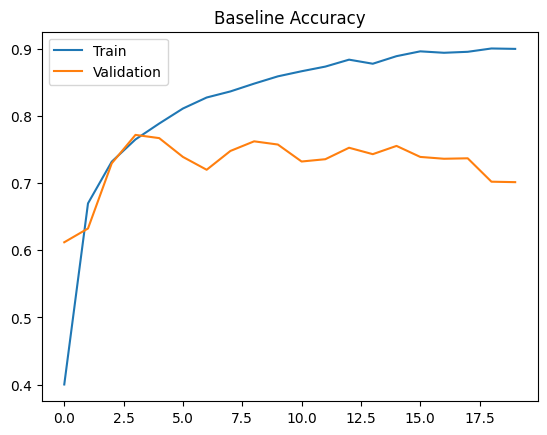

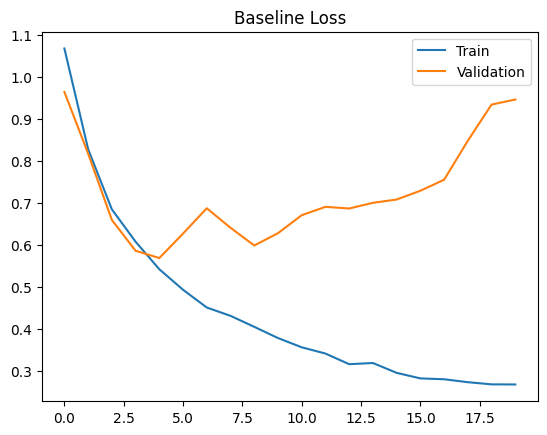

In [13]:
# Plot untuk accuracy
plt.plot(history_baseline.history['accuracy'], label='Train')
plt.plot(history_baseline.history['val_accuracy'], label='Validation')
plt.title('Baseline Accuracy')
plt.legend()
plt.show()

# Plot untuk loss
plt.plot(history_baseline.history['loss'], label='Train')
plt.plot(history_baseline.history['val_loss'], label='Validation')
plt.title('Baseline Loss')
plt.legend()
plt.show()

Dari grafik Baseline Accuracy, terlihat bahwa training accuracy meningkat stabil hingga mendekati nilai yang sangat tinggi, sedangkan validation accuracy hanya meningkat di awal lalu cenderung stagnan dan naik-turun di kisaran tertentu. Pola ini memperkuat indikasi overfitting, karena selisih antara training accuracy dan validation accuracy semakin melebar. Artinya, meskipun model terlihat sangat baik pada data training, performanya pada data validasi masih belum optimal dan kurang stabil. Hal ini menjadi dasar yang kuat untuk melakukan ANN improvement, misalnya dengan penambahan regularisasi, penyesuaian arsitektur model, atau penggunaan teknik seperti early stopping agar model tidak belajar terlalu berlebihan pada data training.

Sementara itu, grafik Baseline Loss, terlihat bahwa nilai training loss terus menurun secara konsisten seiring bertambahnya epoch. Hal ini menunjukkan bahwa model mampu mempelajari pola dari data training dengan cukup baik. Namun, berbeda dengan training loss, validation loss justru cenderung berfluktuasi dan bahkan meningkat setelah beberapa epoch awal. Kondisi ini mengindikasikan bahwa model mulai mengalami overfitting, di mana model semakin “hafal” data training tetapi kemampuan generalisasinya terhadap data validasi tidak ikut membaik. Dengan kata lain, penambahan epoch setelah titik tertentu tidak lagi memberikan peningkatan performa pada data yang belum pernah dilihat model.

In [14]:
baseline_test_loss, baseline_test_acc = model_baseline.evaluate(X_test_pad, y_test)
baseline_test_acc

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7167 - loss: 0.8997


0.7274590134620667

Dari hasil evaluasi model baseline menggunakan data test set, diperoleh nilai accuracy sebesar ±76.8% dengan loss sekitar 0.77. Hasil ini menunjukkan bahwa model mampu melakukan klasifikasi sentimen dengan cukup baik pada data yang benar-benar belum pernah dilihat sebelumnya. Nilai akurasi test yang berada di kisaran yang mirip dengan validation accuracy mengindikasikan bahwa performa model relatif konsisten dan tidak mengalami penurunan drastis saat diuji pada data baru.

# 7. ANN Improvement

## 7.1. Model Definition

In [27]:
VOCAB_SIZE = 10000

# Improved ANN model architecture
model_improved = Sequential([
Input(shape=(50,)),
Embedding(VOCAB_SIZE, 64),
GlobalAveragePooling1D(),
Dense(128, activation='relu'),
Dropout(0.4),
Dense(64, activation='relu'),
Dropout(0.3),
Dense(3, activation='softmax')
])


model_improved.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)


model_improved.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 656,771 (2.51 MB)

 Trainable params: 656,771 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

Dari arsitektur model_improved di atas, dapat dilihat bahwa model ini merupakan pengembangan dari model baseline dengan kompleksitas yang lebih tinggi. Perubahan utama terletak pada peningkatan dimensi embedding dari 32 menjadi 64, serta penambahan jumlah neuron dan layer dense. Embedding layer yang lebih besar memungkinkan model menangkap representasi kata yang lebih kaya, sehingga hubungan semantik antar kata dalam teks sentimen dapat dipelajari dengan lebih baik. Selain itu, penambahan dua hidden layer dengan jumlah neuron yang lebih besar (128 dan 64) bertujuan untuk meningkatkan kemampuan model dalam mempelajari pola non-linear yang lebih kompleks dari data teks. Penggunaan dropout dengan nilai yang lebih besar (0.4 dan 0.3) juga menunjukkan upaya untuk mengurangi risiko overfitting yang sebelumnya terlihat pada model baseline. Dengan kombinasi ini, model improved diharapkan memiliki keseimbangan yang lebih baik antara kemampuan belajar dan generalisasi, sehingga performa pada data validasi dan test dapat menjadi lebih stabil dibandingkan model baseline.

## 7.2. Model Training

In [28]:
# EarlyStopping digunakan untuk menghentikan proses training secara otomatis
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Proses training model improved
history_improved = model_improved.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.3300 - loss: 1.0903 - val_accuracy: 0.7213 - val_loss: 0.7526
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6435 - loss: 0.8667 - val_accuracy: 0.6551 - val_loss: 0.7778
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7221 - loss: 0.6975 - val_accuracy: 0.7022 - val_loss: 0.7046
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7544 - loss: 0.6117 - val_accuracy: 0.6919 - val_loss: 0.7294
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7953 - loss: 0.5286 - val_accuracy: 0.7275 - val_loss: 0.6354
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8244 - loss: 0.4442 - val_accuracy: 0.7425 - val_loss: 0.6490
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8463 - loss: 0.4001 - val_accuracy: 0.6072 - val_loss: 1.0582
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8442 - loss: 0.4276 - val_accuracy: 0

Berdasarkan log training, terlihat bahwa model mengalami fase learning yang sangat cepat di awal epoch, ditandai dengan lonjakan signifikan validation accuracy dari 0.72 pada epoch pertama, meskipun training accuracy masih relatif rendah. Hal ini mengindikasikan bahwa model dengan cepat menangkap pola umum pada data validasi, namun masih belum stabil dalam mempelajari data training secara menyeluruh.

Dengan bertambahnya epoch, training accuracy dan training loss terus membaik secara konsisten, yang menunjukkan bahwa model semakin mampu menyesuaikan diri dengan data training. Namun, kondisi ini tidak sepenuhnya diikuti oleh performa validasi. Pada beberapa epoch (terutama epoch ke-7), terjadi penurunan drastis validation accuracy disertai lonjakan validation loss, meskipun training accuracy tetap tinggi. Pola ini merupakan indikasi kuat bahwa model mulai overfitting, yaitu terlalu fokus menghafal data training sehingga kehilangan kemampuan generalisasi terhadap data baru.

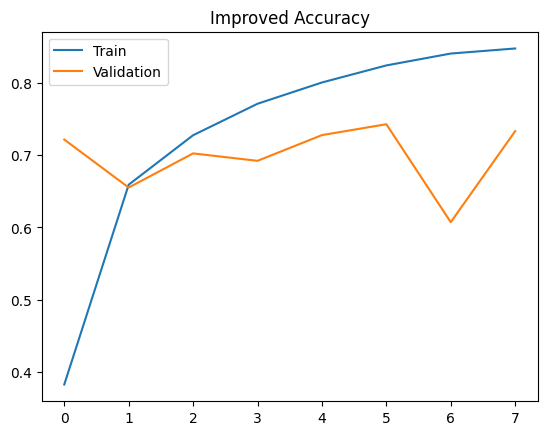

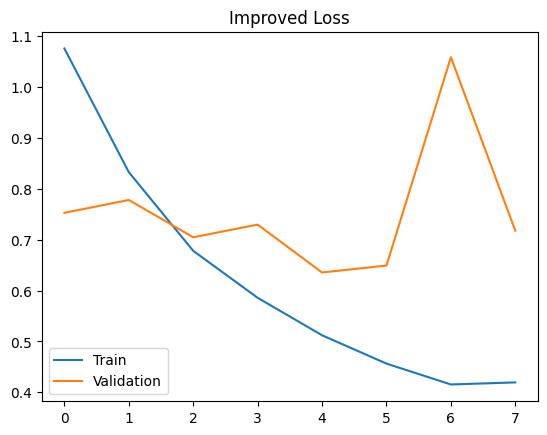

In [29]:
# Plot untuk accuracy
plt.plot(history_improved.history['accuracy'], label='Train')
plt.plot(history_improved.history['val_accuracy'], label='Validation')
plt.title('Improved Accuracy')
plt.legend()
plt.show()

# Plot untuk loss
plt.plot(history_improved.history['loss'], label='Train')
plt.plot(history_improved.history['val_loss'], label='Validation')
plt.title('Improved Loss')
plt.legend()
plt.show()

Dari grafik Improved Loss, terlihat bahwa training loss menurun secara stabil dan konsisten seiring bertambahnya epoch, menandakan proses pembelajaran model berjalan dengan baik. Sementara itu, validation loss cenderung lebih stabil dibandingkan baseline, meskipun masih terdapat fluktuasi pada beberapa epoch. Lonjakan validation loss yang cukup tajam di salah satu epoch mengindikasikan adanya ketidakkonsistenan performa pada data validasi, namun secara umum nilainya kembali menurun di epoch akhir. Hal ini menunjukkan bahwa tingkat overfitting telah berkurang, dan model mampu mempertahankan performa yang relatif lebih baik pada data yang belum pernah dilihat.

Hal yang sama juga dapat terlihat pada grafik Improved Accuracy. Akurasi training meningkat secara bertahap dan lebih terkontrol, tanpa lonjakan ekstrem, hingga mencapai nilai yang cukup tinggi. Di sisi lain, akurasi validasi menunjukkan tren yang lebih mengikuti pola training dibandingkan baseline, meskipun masih mengalami fluktuasi di beberapa epoch. Rentang perbedaan antara akurasi training dan validasi terlihat lebih kecil, yang mengindikasikan bahwa model memiliki kemampuan generalisasi yang lebih baik dibandingkan baseline. Secara keseluruhan, perbaikan yang dilakukan berhasil meningkatkan keseimbangan antara pembelajaran pada data training dan performa pada data validasi, sehingga model menjadi lebih robust dan tidak sekadar menghafal data training.

## 7.3. Model Evaluation

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
              precision    recall  f1-score   support

    negative       0.91      0.76      0.83       918
     neutral       0.49      0.80      0.61       310
    positive       0.79      0.64      0.70       236

    accuracy                           0.75      1464
   macro avg       0.73      0.73      0.71      1464
weighted avg       0.80      0.75      0.76      1464



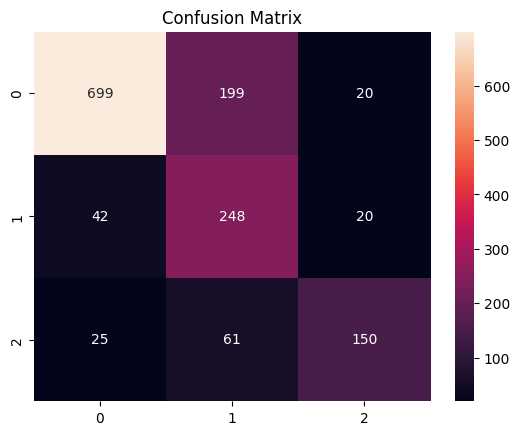

In [30]:
y_pred = np.argmax(model_improved.predict(X_test_pad), axis=1)


print(classification_report(y_test, y_pred, target_names=le.classes_))


sns.heatmap(confusion_matrix(y_test, y_pred,), annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

Output confusion matrix menunjukkan bahwa model memiliki performa terbaik pada kelas negative, namun masih mengalami kesulitan dalam membedakan kelas neutral dan positive. Kesalahan prediksi paling banyak terjadi ketika data neutral diklasifikasikan sebagai negative, yang mengindikasikan adanya overlap linguistik antar kelas serta pengaruh ketidakseimbangan data.

In [31]:
improved_test_loss, improved_test_acc = model_improved.evaluate(X_test_pad, y_test)
improved_test_acc

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7402 - loss: 0.6079


0.749316930770874

# 8. Model Saving

In [35]:
model_improved.save('best_ann_sentiment_model.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# 9. Model Inference

Model inference ada pada file 'P2G7_muhammad_damar_inf.ipynb'. Silakan buka file tersebut.

# 10. Conclusion & Recommendation

Berdasarkan seluruh rangkaian eksperimen yang telah dilakukan, mulai dari pembangunan model baseline hingga model improved, dapat disimpulkan bahwa model klasifikasi sentimen yang dibangun sudah mampu menangkap pola umum sentimen pada data tweet maskapai dengan performa yang cukup baik. Model baseline menunjukkan kemampuan belajar yang stabil, namun mulai memperlihatkan indikasi overfitting, di mana akurasi training terus meningkat sementara performa validasi cenderung stagnan dan fluktuatif. Hal ini mengindikasikan bahwa meskipun model belajar dengan baik pada data latih, generalisasinya masih terbatas.

Penerapan model improved dengan penambahan arsitektur Dense yang lebih dalam, Dropout, serta Early Stopping terbukti membantu mengendalikan overfitting. Training berhenti lebih awal pada kondisi terbaik berdasarkan validation loss, sehingga model tidak dipaksa belajar berlebihan. Hasil evaluasi pada data uji menunjukkan akurasi sekitar 76%, dengan performa terbaik pada kelas negative, cukup baik pada positive, dan masih relatif lemah pada kelas neutral. Confusion matrix dan classification report memperlihatkan bahwa kelas neutral sering tertukar dengan negative atau positive, yang menunjukkan adanya tumpang tindih semantik antar kelas sentimen.

Dari sisi inferensi, model menunjukkan perilaku yang cukup masuk akal ketika diterapkan pada data baru. Kalimat dengan sentimen yang sangat jelas seperti “Worst experience ever, very disappointed” berhasil diprediksi sebagai negative, sementara kalimat dengan ekspresi emosional kuat seperti “I love flying with this airline” diprediksi sebagai positive. Namun, pada kalimat dengan nuansa ambigu atau campuran, seperti “The flight was delayed and the service was terrible”, model memprediksi neutral, yang mengindikasikan bahwa model cenderung berhati-hati ketika menemukan konflik konteks atau struktur kalimat yang tidak sepenuhnya konsisten. Hal serupa juga terlihat pada kalimat “The flight was okay, nothing special”, yang diprediksi sebagai negative, menunjukkan bahwa frasa netral cenderung ditarik ke kelas mayoritas atau sentimen ringan yang dianggap negatif.

Secara keseluruhan, model sudah cukup andal untuk digunakan sebagai sentiment analyzer dasar pada domain tweet maskapai, terutama untuk mendeteksi sentimen negatif yang krusial dalam konteks layanan pelanggan. Meski demikian, masih terdapat ruang perbaikan, khususnya dalam membedakan sentimen netral dan sentimen negatif ringan. Peningkatan kualitas data, penyeimbangan kelas yang lebih optimal, serta eksplorasi arsitektur berbasis sequence seperti LSTM atau transformer berpotensi meningkatkan performa model di masa mendatang.